In [2]:
# Load Data & Best Model
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/creditcard.csv")

x = df.drop("Class", axis=1)
y = df["Class"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(x_train, y_train)

print("Model Loaded & Trained!")

Model Loaded & Trained!


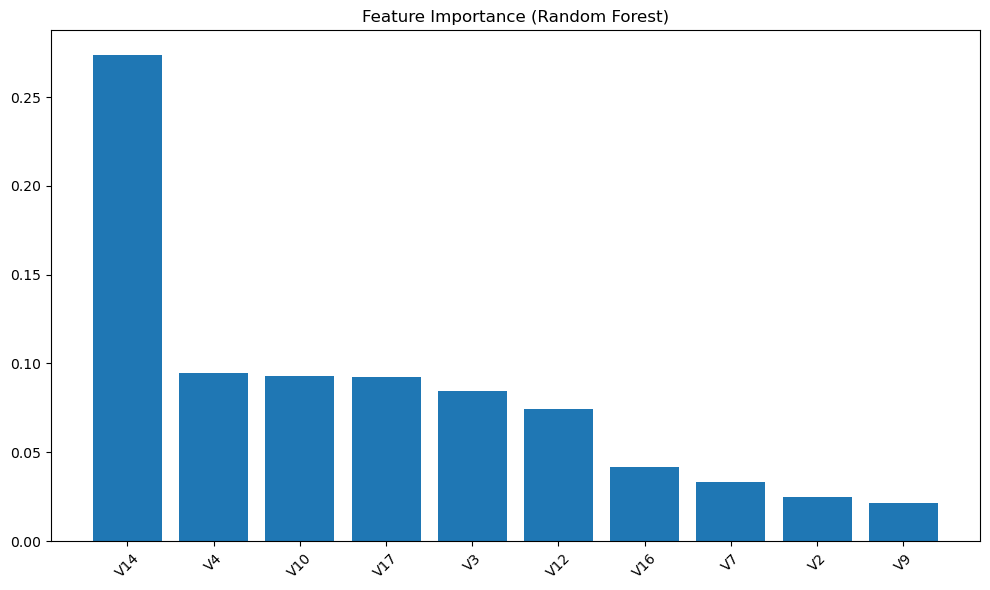

1. V14 = 0.2739
2. V4 = 0.0949
3. V10 = 0.0932
4. V17 = 0.0925
5. V3 = 0.0845
6. V12 = 0.0742
7. V16 = 0.0418
8. V7 = 0.0331
9. V2 = 0.0249
10. V9 = 0.0212


In [4]:
# Feature Importance
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(10), importances[indices][:10], align="center")
plt.xticks(range(10), x.columns[indices][:10], rotation=45)
plt.tight_layout()
plt.show()

for i in range(10):
    print(f"{i+1}. {x.columns[indices][i]} = {importances[indices][i]:.4f}")

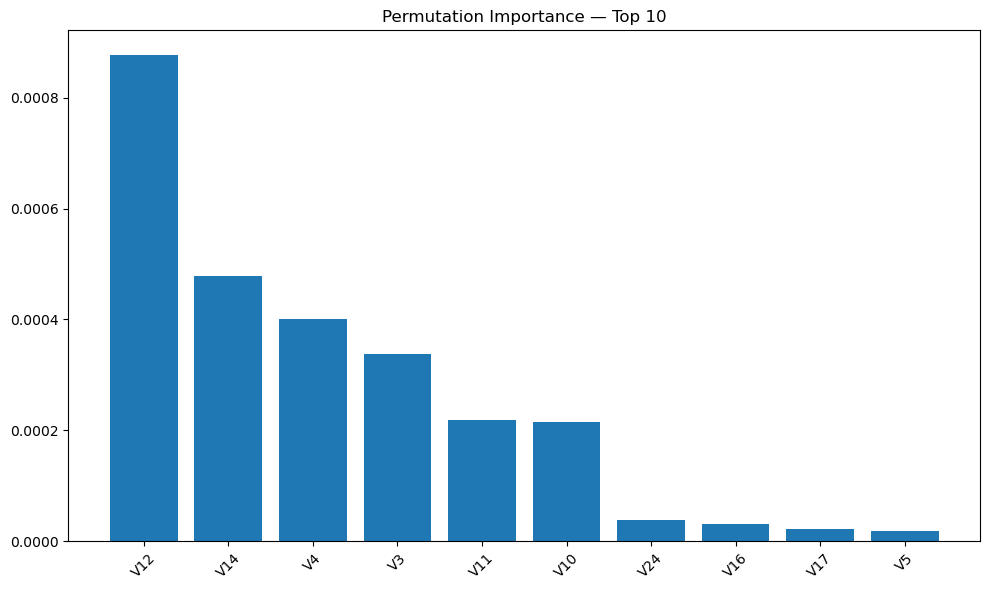

In [5]:
# Permutation Importance
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf, x_test, y_test, n_repeats=5, random_state=42
)

sorted_idx = perm.importances_mean.argsort()[::-1][:10]

plt.figure(figsize=(10,6))
plt.title("Permutation Importance — Top 10")
plt.bar(
    x.columns[sorted_idx],
    perm.importances_mean[sorted_idx]
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

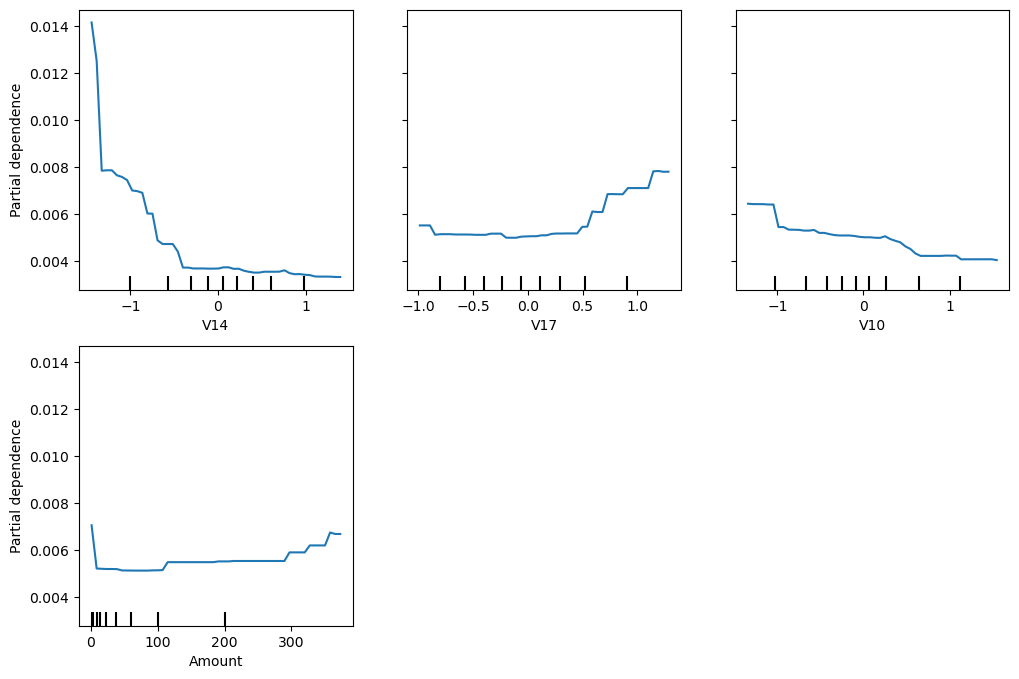

In [9]:
# Partial Dependence Plots (PDP)
from sklearn.inspection import PartialDependenceDisplay

features = ["V14", "V17", "V10", "Amount"]

fig, ax = plt.subplots(figsize=(12, 8))

PartialDependenceDisplay.from_estimator(
    rf,
    x_test,
    features,
    kind="average",
    grid_resolution=50,
    ax=ax
)
plt.show()

In [10]:
# SHAP Setup
import shap

shap.initjs()

x_sample = x_test.sample(300, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(x_sample)

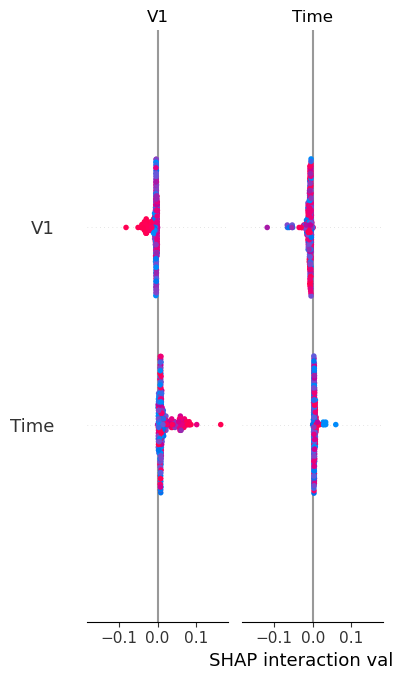

In [13]:
# SHAP Summary Plot
shap.summary_plot(shap_values, x_sample)

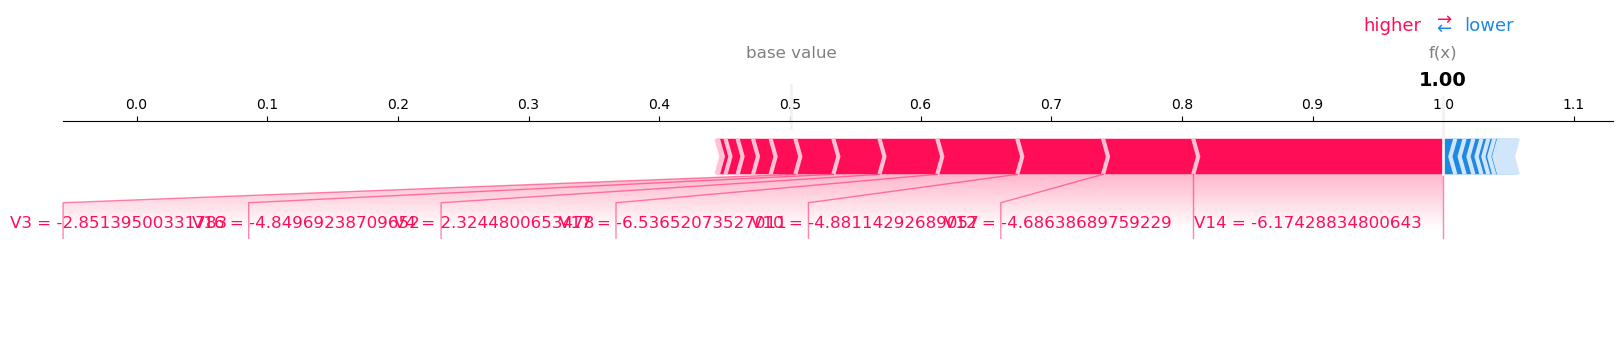

In [29]:
# SHAP Force Plot for 1 Single Fraud Case

fraud_case = x_test[y_test == 1].iloc[[0]]

shap_fixed = shap_single[0, :, 1]   # (30,)

base_value = explainer.expected_value[1]

shap.initjs()

shap.force_plot(
    base_value,
    shap_fixed,
    fraud_case.iloc[0],
    matplotlib=True
)